Alternative version to run on colab.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content
# clone my repository in /content
!git clone https://github.com/MEI-JL/ME6409_ML.git
# copy dataset and unzip
!cp -r ./drive/MyDrive/Wearable_notebooks/ProcessedDataTrimmed.zip ./ME6409_ML/
%cd ./ME6409_ML/
!unzip -q ProcessedDataTrimmed.zip -d ./

/content
Cloning into 'ME6409_ML'...
remote: Enumerating objects: 117, done.
remote: Counting objects: 100% (117/117), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 117 (delta 71), reused 75 (delta 33), pack-reused 0 (from 0)
Receiving objects: 100% (117/117), 43.40 KiB | 753.00 KiB/s, done.
Resolving deltas: 100% (71/71), done.
/content/ME6409_ML


In [3]:
import torch
from helpers.data_management import (DatasetConfig,
    create_LOSO_dataset_dataloader)
from helpers.constants import *
from helpers.visualization import (inspect_knee_moment_dataset, plot_loss,
                                   prediction_overlay, evaluate_visualize_model)
from helpers.modules import KneeCNN, KneeTCN, KneeLSTM
from helpers.running import train_model, evaluate_model, loso_cross_validation

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

batch_size = 512
num_epoches = 5
lr = 1e-3

Using device: cuda


# Dataset and Network Example

In [ ]:
leave_one_out_subject = SUBJECTS[2]

cfg = DatasetConfig(tasks = PERIODIC_TASK_PREFIXES)
train_dataset, test_dataset, train_dataloader, test_dataloader = \
    create_LOSO_dataset_dataloader(
        leave_one_out_subject, dataset_cfg=cfg, batch_size=batch_size)

print(len(train_dataset))
print(len(test_dataset))

iterator = iter(train_dataset) # only for visualization

25293
3161


In [ ]:
# visualize dataset
x,y = next(iterator)
_,_ = inspect_knee_moment_dataset(torch.squeeze(x),y)

In [ ]:
cnn_model = KneeCNN().to(device)
checkpoint = train_model(cnn_model, train_dataloader, test_dataloader,
                         num_epochs=10)
plot_loss(checkpoint['train_losses'], checkpoint['test_losses'])

In [ ]:
preds, targets, rmse, r2 = evaluate_model(cnn_model, test_dataloader,
                                          train_dataset.scaler_y)
print(f'RMSE: {rmse:.4f} Nm')
print(f'R\u00b2:   {r2:.4f}')
prediction_overlay(targets, preds, rmse, r2)

# LOSO Evaluation

### Change Architecture

Evaluating for test subject AB03
Train: 86021 windows |  Test: 13953 windows
Epoch   0 | Train Loss: 0.2225 | Test Loss: 0.3049
Epoch   4 | Train Loss: 0.1330 | Test Loss: 0.3314
Evaluating for test subject AB06
Train: 84621 windows |  Test: 15353 windows
Epoch   0 | Train Loss: 0.2256 | Test Loss: 0.3571
Epoch   4 | Train Loss: 0.1328 | Test Loss: 0.2722
Evaluating for test subject AB08
Train: 84741 windows |  Test: 15233 windows
Epoch   0 | Train Loss: 0.2258 | Test Loss: 0.3058
Epoch   4 | Train Loss: 0.1355 | Test Loss: 0.3282
Evaluating for test subject AB09
Train: 84057 windows |  Test: 15918 windows
Epoch   0 | Train Loss: 0.2246 | Test Loss: 0.1562
Epoch   4 | Train Loss: 0.1312 | Test Loss: 0.1533
Evaluating for test subject AB11
Train: 85909 windows |  Test: 14068 windows
Epoch   0 | Train Loss: 0.2232 | Test Loss: 0.2190
Epoch   4 | Train Loss: 0.1295 | Test Loss: 0.2036
Evaluating for test subject AB12
Train: 88716 windows |  Test: 11261 windows
Epoch   0 | Train Loss: 0.23

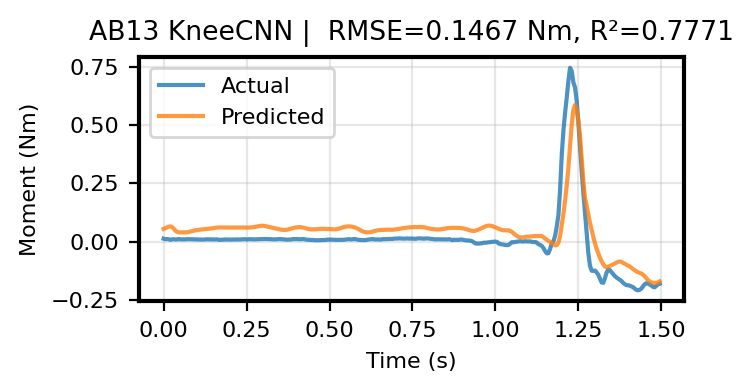

In [6]:
experiment_name = "base_"
# CNN
rmses, r2s, last_model = loso_cross_validation(
    KneeCNN,
    num_epoches = num_epoches,
    experiment_name = experiment_name,
    lr = lr,
    )
# predict and plot.
evaluate_visualize_model(
    last_model,
    SUBJECTS_SUBSET[-1],
    dataset_cfg=DatasetConfig(test_tasks = NON_PERIODIC_TASK_PREFIXES),
    )

Evaluating for test subject AB03
Train: 86021 windows |  Test: 13953 windows
Epoch   0 | Train Loss: 0.2099 | Test Loss: 0.3650
Epoch   4 | Train Loss: 0.1018 | Test Loss: 0.3215
Evaluating for test subject AB06
Train: 84621 windows |  Test: 15353 windows
Epoch   0 | Train Loss: 0.2119 | Test Loss: 0.3836
Epoch   4 | Train Loss: 0.1034 | Test Loss: 0.3188
Evaluating for test subject AB08
Train: 84741 windows |  Test: 15233 windows
Epoch   0 | Train Loss: 0.2153 | Test Loss: 0.3246
Epoch   4 | Train Loss: 0.0967 | Test Loss: 0.2856
Evaluating for test subject AB09
Train: 84057 windows |  Test: 15918 windows
Epoch   0 | Train Loss: 0.2215 | Test Loss: 0.1991
Epoch   4 | Train Loss: 0.1084 | Test Loss: 0.1445
Evaluating for test subject AB11
Train: 85909 windows |  Test: 14068 windows
Epoch   0 | Train Loss: 0.2152 | Test Loss: 0.1648
Epoch   4 | Train Loss: 0.1046 | Test Loss: 0.1539
Evaluating for test subject AB12
Train: 88716 windows |  Test: 11261 windows
Epoch   0 | Train Loss: 0.22

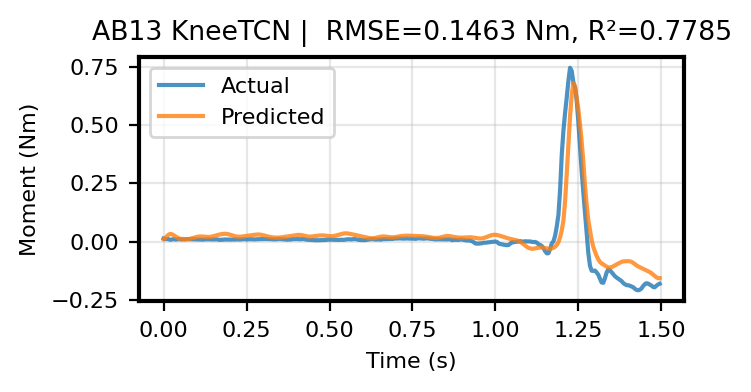

In [7]:
# TCN
rmses, r2s, last_model = loso_cross_validation(
    KneeTCN,
    num_epoches = num_epoches,
    experiment_name = experiment_name,
    lr = lr
    )
# predict and plot.
evaluate_visualize_model(
    last_model,
    SUBJECTS_SUBSET[-1],
    dataset_cfg=DatasetConfig(test_tasks = NON_PERIODIC_TASK_PREFIXES),
    )

Evaluating for test subject AB03
Train: 86021 windows |  Test: 13953 windows
Epoch   0 | Train Loss: 0.1946 | Test Loss: 0.3238
Epoch   4 | Train Loss: 0.0989 | Test Loss: 0.2950
Evaluating for test subject AB06
Train: 84621 windows |  Test: 15353 windows
Epoch   0 | Train Loss: 0.1954 | Test Loss: 0.3647
Epoch   4 | Train Loss: 0.0936 | Test Loss: 0.2897
Evaluating for test subject AB08
Train: 84741 windows |  Test: 15233 windows
Epoch   0 | Train Loss: 0.1996 | Test Loss: 0.3147
Epoch   4 | Train Loss: 0.0937 | Test Loss: 0.2967
Evaluating for test subject AB09
Train: 84057 windows |  Test: 15918 windows
Epoch   0 | Train Loss: 0.1983 | Test Loss: 0.1431
Epoch   4 | Train Loss: 0.0996 | Test Loss: 0.1480
Evaluating for test subject AB11
Train: 85909 windows |  Test: 14068 windows
Epoch   0 | Train Loss: 0.1949 | Test Loss: 0.1995
Epoch   4 | Train Loss: 0.1000 | Test Loss: 0.1720
Evaluating for test subject AB12
Train: 88716 windows |  Test: 11261 windows
Epoch   0 | Train Loss: 0.20

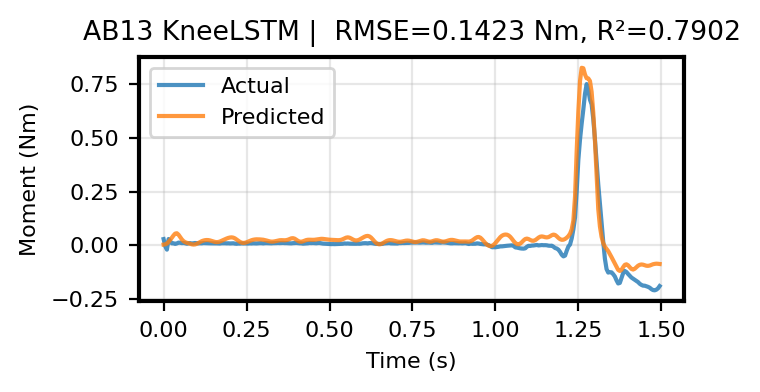

In [8]:
# LSTM
rmses, r2s, last_model = loso_cross_validation(
    KneeLSTM,
    dataset_cfg = DatasetConfig(full_horizon_output = True),
    num_epoches = num_epoches,
    experiment_name = experiment_name,
    lr = lr
    )
# predict and plot.
evaluate_visualize_model(
    last_model,
    SUBJECTS_SUBSET[-1],
    dataset_cfg=DatasetConfig(
        full_horizon_output = True,
        test_tasks = NON_PERIODIC_TASK_PREFIXES
        ),
    )

## Hyperparameter tuning

### Increasing hidden layer size (default is 64)

Evaluating for test subject AB03
Train: 86021 windows |  Test: 13953 windows
Epoch   0 | Train Loss: 0.2052 | Test Loss: 0.3520
Epoch   4 | Train Loss: 0.1131 | Test Loss: 0.3081
Evaluating for test subject AB06
Train: 84621 windows |  Test: 15353 windows
Epoch   0 | Train Loss: 0.2034 | Test Loss: 0.3229
Epoch   4 | Train Loss: 0.1140 | Test Loss: 0.3757
Evaluating for test subject AB08
Train: 84741 windows |  Test: 15233 windows
Epoch   0 | Train Loss: 0.2086 | Test Loss: 0.2758
Epoch   4 | Train Loss: 0.1111 | Test Loss: 0.2624
Evaluating for test subject AB09
Train: 84057 windows |  Test: 15918 windows
Epoch   0 | Train Loss: 0.2052 | Test Loss: 0.1439
Epoch   4 | Train Loss: 0.1137 | Test Loss: 0.1497
Evaluating for test subject AB11
Train: 85909 windows |  Test: 14068 windows
Epoch   0 | Train Loss: 0.2080 | Test Loss: 0.1658
Epoch   4 | Train Loss: 0.1146 | Test Loss: 0.1928
Evaluating for test subject AB12
Train: 88716 windows |  Test: 11261 windows
Epoch   0 | Train Loss: 0.21

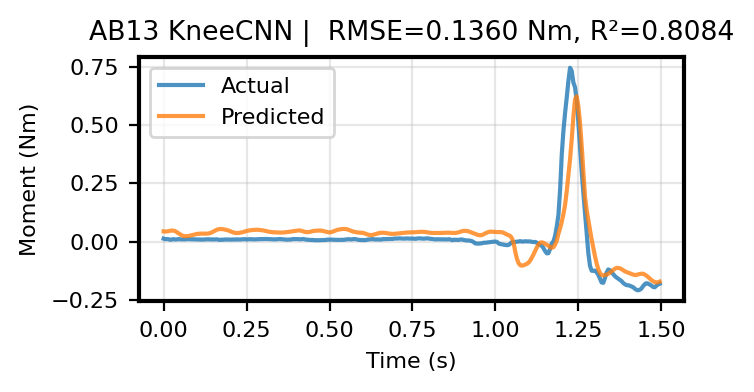

In [9]:
experiment_name = "layer_"
# CNN, hidden size = 128.
rmses, r2s, last_model = loso_cross_validation(
    KneeCNN,
    num_epoches = num_epoches,
    hidden_layer_size = 128,
    experiment_name = experiment_name
    )
# predict and plot.
evaluate_visualize_model(
    last_model,
    SUBJECTS_SUBSET[-1],
    dataset_cfg=DatasetConfig(test_tasks = NON_PERIODIC_TASK_PREFIXES),
    )

Evaluating for test subject AB03
Train: 86021 windows |  Test: 13953 windows
Epoch   0 | Train Loss: 0.1844 | Test Loss: 0.3187
Epoch   4 | Train Loss: 0.0792 | Test Loss: 0.3468
Evaluating for test subject AB06
Train: 84621 windows |  Test: 15353 windows
Epoch   0 | Train Loss: 0.1903 | Test Loss: 0.3447
Epoch   4 | Train Loss: 0.0784 | Test Loss: 0.3215
Evaluating for test subject AB08
Train: 84741 windows |  Test: 15233 windows
Epoch   0 | Train Loss: 0.1858 | Test Loss: 0.3215
Epoch   4 | Train Loss: 0.0747 | Test Loss: 0.2420
Evaluating for test subject AB09
Train: 84057 windows |  Test: 15918 windows
Epoch   0 | Train Loss: 0.2048 | Test Loss: 0.1437
Epoch   4 | Train Loss: 0.0834 | Test Loss: 0.1498
Evaluating for test subject AB11
Train: 85909 windows |  Test: 14068 windows
Epoch   0 | Train Loss: 0.1864 | Test Loss: 0.2005
Epoch   4 | Train Loss: 0.0798 | Test Loss: 0.1780
Evaluating for test subject AB12
Train: 88716 windows |  Test: 11261 windows
Epoch   0 | Train Loss: 0.20

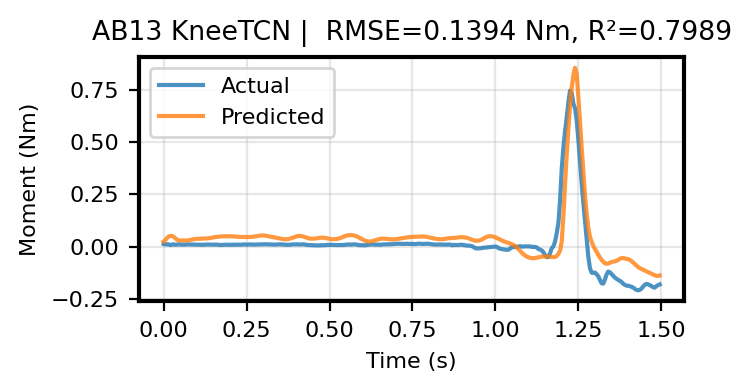

In [10]:
# TCN, hidden size = 128.
rmses, r2s, last_model = loso_cross_validation(
    KneeTCN,
    num_epoches = num_epoches,
    hidden_layer_size = 128,
    experiment_name = experiment_name
    )
# predict and plot.
evaluate_visualize_model(
    last_model,
    SUBJECTS_SUBSET[-1],
    dataset_cfg=DatasetConfig(test_tasks = NON_PERIODIC_TASK_PREFIXES),
    )

### Changng window size (default is 100)

Evaluating for test subject AB03
Train: 85481 windows |  Test: 13863 windows
Epoch   0 | Train Loss: 0.2471 | Test Loss: 0.3827
Epoch   4 | Train Loss: 0.1338 | Test Loss: 0.3437
Evaluating for test subject AB06
Train: 84081 windows |  Test: 15263 windows
Epoch   0 | Train Loss: 0.2547 | Test Loss: 0.3582
Epoch   4 | Train Loss: 0.1368 | Test Loss: 0.3390
Evaluating for test subject AB08
Train: 84201 windows |  Test: 15143 windows
Epoch   0 | Train Loss: 0.2544 | Test Loss: 0.2963
Epoch   4 | Train Loss: 0.1343 | Test Loss: 0.2907
Evaluating for test subject AB09
Train: 83517 windows |  Test: 15828 windows
Epoch   0 | Train Loss: 0.2479 | Test Loss: 0.1603
Epoch   4 | Train Loss: 0.1329 | Test Loss: 0.1701
Evaluating for test subject AB11
Train: 85369 windows |  Test: 13978 windows
Epoch   0 | Train Loss: 0.2496 | Test Loss: 0.1923
Epoch   4 | Train Loss: 0.1306 | Test Loss: 0.1804
Evaluating for test subject AB12
Train: 88176 windows |  Test: 11171 windows
Epoch   0 | Train Loss: 0.26

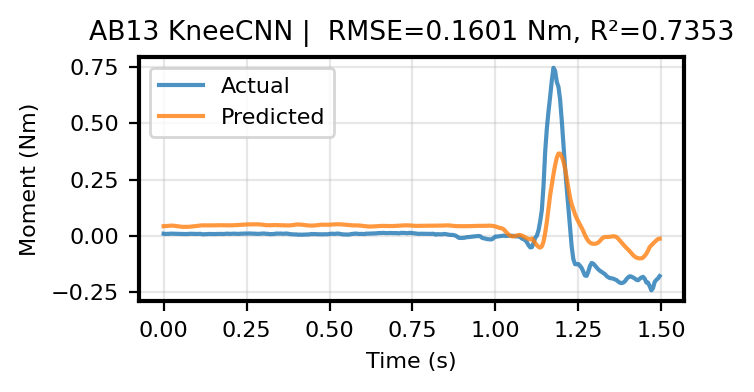

In [11]:
experiment_name = "window_"
# CNN
rmses, r2s, last_model = loso_cross_validation(
    KneeCNN,
    dataset_cfg = DatasetConfig(window_size = 100),
    num_epoches = num_epoches,
    experiment_name = experiment_name
    )
# predict and plot.
evaluate_visualize_model(
    last_model,
    SUBJECTS_SUBSET[-1],
    dataset_cfg=DatasetConfig(test_tasks = NON_PERIODIC_TASK_PREFIXES,
                              window_size = 100),
    )

Evaluating for test subject AB03
Train: 85481 windows |  Test: 13863 windows
Epoch   0 | Train Loss: 0.2538 | Test Loss: 0.3910
Epoch   4 | Train Loss: 0.1009 | Test Loss: 0.4044
Evaluating for test subject AB06
Train: 84081 windows |  Test: 15263 windows
Epoch   0 | Train Loss: 0.2376 | Test Loss: 0.4125
Epoch   4 | Train Loss: 0.1009 | Test Loss: 0.3199
Evaluating for test subject AB08
Train: 84201 windows |  Test: 15143 windows
Epoch   0 | Train Loss: 0.2325 | Test Loss: 0.2703
Epoch   4 | Train Loss: 0.1007 | Test Loss: 0.2716
Evaluating for test subject AB09
Train: 83517 windows |  Test: 15828 windows
Epoch   0 | Train Loss: 0.2469 | Test Loss: 0.1710
Epoch   4 | Train Loss: 0.1079 | Test Loss: 0.1682
Evaluating for test subject AB11
Train: 85369 windows |  Test: 13978 windows
Epoch   0 | Train Loss: 0.2347 | Test Loss: 0.1284
Epoch   4 | Train Loss: 0.1039 | Test Loss: 0.2496
Evaluating for test subject AB12
Train: 88176 windows |  Test: 11171 windows
Epoch   0 | Train Loss: 0.26

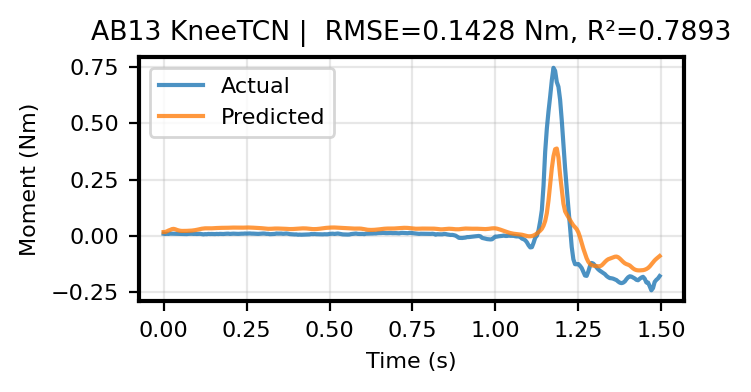

In [12]:
# TCN
rmses, r2s, last_model = loso_cross_validation(
    KneeTCN,
    dataset_cfg = DatasetConfig(window_size = 100),
    num_epoches = num_epoches,
    experiment_name = experiment_name
    )
# predict and plot.
evaluate_visualize_model(
    last_model,
    SUBJECTS_SUBSET[-1],
    dataset_cfg=DatasetConfig(test_tasks = NON_PERIODIC_TASK_PREFIXES,
                              window_size = 100),
    )

## Sensor Ablation Studies (TCN)

Evaluating for test subject AB03
Train: 86021 windows |  Test: 13953 windows
Epoch   0 | Train Loss: 0.2408 | Test Loss: 0.3130
Epoch   4 | Train Loss: 0.1235 | Test Loss: 0.3477
Evaluating for test subject AB06
Train: 84621 windows |  Test: 15353 windows
Epoch   0 | Train Loss: 0.2354 | Test Loss: 0.3761
Epoch   4 | Train Loss: 0.1138 | Test Loss: 0.3319
Evaluating for test subject AB08
Train: 84741 windows |  Test: 15233 windows
Epoch   0 | Train Loss: 0.2433 | Test Loss: 0.3237
Epoch   4 | Train Loss: 0.1181 | Test Loss: 0.3222
Evaluating for test subject AB09
Train: 84057 windows |  Test: 15918 windows
Epoch   0 | Train Loss: 0.2451 | Test Loss: 0.1532
Epoch   4 | Train Loss: 0.1238 | Test Loss: 0.1723
Evaluating for test subject AB11
Train: 85909 windows |  Test: 14068 windows
Epoch   0 | Train Loss: 0.2294 | Test Loss: 0.2289
Epoch   4 | Train Loss: 0.1129 | Test Loss: 0.2657
Evaluating for test subject AB12
Train: 88716 windows |  Test: 11261 windows
Epoch   0 | Train Loss: 0.23

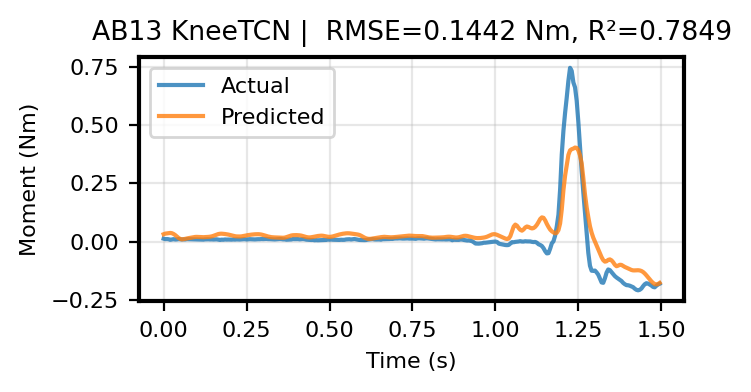

In [14]:
# removing Shank IMU
rmses, r2s, last_model = loso_cross_validation(
    KneeTCN,
    dataset_cfg = DatasetConfig(ablated_sensors = ["imu_shank"]),
    num_epoches = num_epoches,
    experiment_name = "ablation_shank_"
    )
evaluate_visualize_model(
    last_model,
    SUBJECTS_SUBSET[-1],
    dataset_cfg=DatasetConfig(test_tasks = NON_PERIODIC_TASK_PREFIXES,
                              ablated_sensors = ["imu_shank"]),
    )

Evaluating for test subject AB03
Train: 86021 windows |  Test: 13953 windows
Epoch   0 | Train Loss: 0.3570 | Test Loss: 0.4870
Epoch   4 | Train Loss: 0.1833 | Test Loss: 0.4278
Evaluating for test subject AB06
Train: 84621 windows |  Test: 15353 windows
Epoch   0 | Train Loss: 0.3506 | Test Loss: 0.4619
Epoch   4 | Train Loss: 0.1715 | Test Loss: 0.3577
Evaluating for test subject AB08
Train: 84741 windows |  Test: 15233 windows
Epoch   0 | Train Loss: 0.3551 | Test Loss: 0.5060
Epoch   4 | Train Loss: 0.1697 | Test Loss: 0.4852
Evaluating for test subject AB09
Train: 84057 windows |  Test: 15918 windows
Epoch   0 | Train Loss: 0.3565 | Test Loss: 0.2609
Epoch   4 | Train Loss: 0.1730 | Test Loss: 0.3185
Evaluating for test subject AB11
Train: 85909 windows |  Test: 14068 windows
Epoch   0 | Train Loss: 0.3499 | Test Loss: 0.2662
Epoch   4 | Train Loss: 0.1762 | Test Loss: 0.2748
Evaluating for test subject AB12
Train: 88716 windows |  Test: 11261 windows
Epoch   0 | Train Loss: 0.36

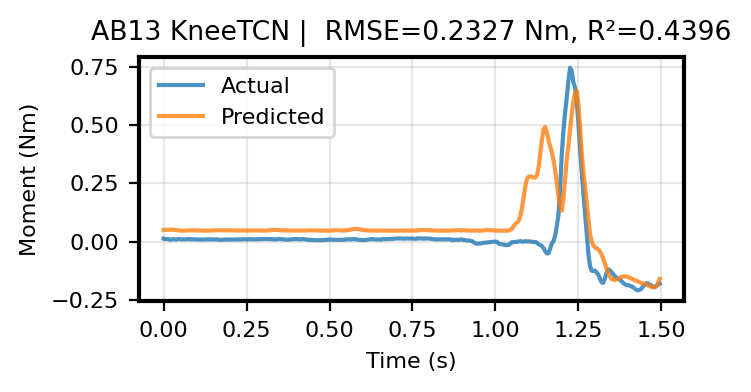

In [15]:
# removing Shank IMU, knee
rmses, r2s, last_model = loso_cross_validation(
    KneeTCN,
    dataset_cfg = DatasetConfig(
        ablated_sensors = ["imu_shank", "angle", "velocity"]),
    num_epoches = num_epoches,
    experiment_name = "ablation_shank_knee_"
    )
evaluate_visualize_model(
    last_model,
    SUBJECTS_SUBSET[-1],
    dataset_cfg=DatasetConfig(test_tasks = NON_PERIODIC_TASK_PREFIXES,
                              ablated_sensors = ["imu_shank", "angle", "velocity"]),
    )

## Periodic vs non-Periodic

Evaluating for test subject AB03
Train: 18969 windows |  Test: 10792 windows
Epoch   0 | Train Loss: 0.2072 | Test Loss: 0.8491
Epoch   4 | Train Loss: 0.0623 | Test Loss: 0.8843
Evaluating for test subject AB06
Train: 18969 windows |  Test: 12192 windows
Epoch   0 | Train Loss: 0.2204 | Test Loss: 0.5439
Epoch   4 | Train Loss: 0.0637 | Test Loss: 0.6009
Evaluating for test subject AB08
Train: 18969 windows |  Test: 12072 windows
Epoch   0 | Train Loss: 0.2463 | Test Loss: 0.5844
Epoch   4 | Train Loss: 0.0580 | Test Loss: 0.5066
Evaluating for test subject AB09
Train: 18969 windows |  Test: 12757 windows
Epoch   0 | Train Loss: 0.2400 | Test Loss: 0.2236
Epoch   4 | Train Loss: 0.0658 | Test Loss: 0.2041
Evaluating for test subject AB11
Train: 18969 windows |  Test: 10906 windows
Epoch   0 | Train Loss: 0.2311 | Test Loss: 0.1980
Epoch   4 | Train Loss: 0.0652 | Test Loss: 0.1831
Evaluating for test subject AB12
Train: 18969 windows |  Test: 8099 windows
Epoch   0 | Train Loss: 0.210

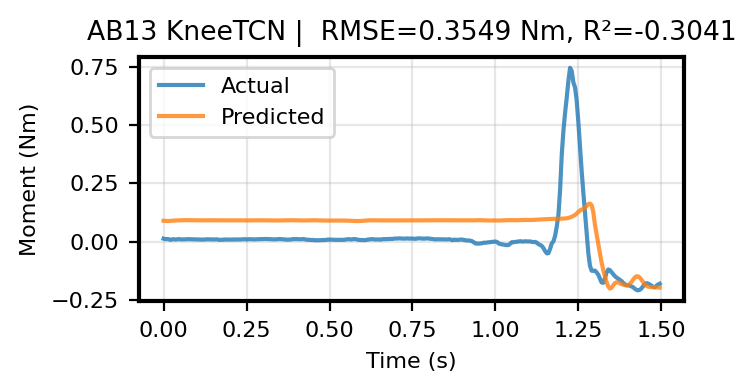

In [16]:
rmses, r2s, last_model = loso_cross_validation(
    KneeTCN,
    dataset_cfg = DatasetConfig(tasks = PERIODIC_TASK_PREFIXES,
                                test_tasks = NON_PERIODIC_TASK_PREFIXES
                                ),
    num_epoches = num_epoches,
    experiment_name = "periodic_train_"
    )
evaluate_visualize_model(
    last_model,
    SUBJECTS_SUBSET[-1],
    dataset_cfg=DatasetConfig(tasks = PERIODIC_TASK_PREFIXES, # for scaler fitting
                              test_tasks = NON_PERIODIC_TASK_PREFIXES),
    )

Evaluating for test subject AB03
Train: 67053 windows |  Test: 3161 windows
Epoch   0 | Train Loss: 0.2212 | Test Loss: 3.0120
Epoch   4 | Train Loss: 0.1098 | Test Loss: 1.7086
Evaluating for test subject AB06
Train: 65653 windows |  Test: 3161 windows
Epoch   0 | Train Loss: 0.2314 | Test Loss: 3.2173
Epoch   4 | Train Loss: 0.1191 | Test Loss: 2.6231
Evaluating for test subject AB08
Train: 65773 windows |  Test: 3161 windows
Epoch   0 | Train Loss: 0.2241 | Test Loss: 3.2458
Epoch   4 | Train Loss: 0.1095 | Test Loss: 2.1983
Evaluating for test subject AB09
Train: 65088 windows |  Test: 3161 windows
Epoch   0 | Train Loss: 0.2420 | Test Loss: 2.4564
Epoch   4 | Train Loss: 0.1323 | Test Loss: 1.7203
Evaluating for test subject AB11
Train: 66939 windows |  Test: 3161 windows
Epoch   0 | Train Loss: 0.2306 | Test Loss: 3.1715
Epoch   4 | Train Loss: 0.1205 | Test Loss: 2.3211
Evaluating for test subject AB12
Train: 69746 windows |  Test: 3161 windows
Epoch   0 | Train Loss: 0.2398 | T

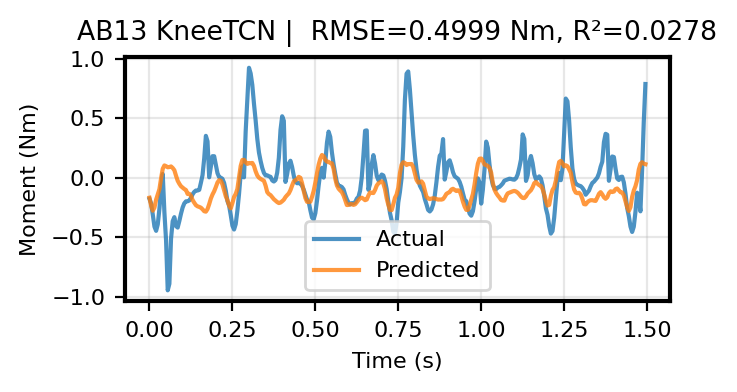

In [17]:
rmses, r2s, last_model = loso_cross_validation(
    KneeTCN,
    dataset_cfg = DatasetConfig(tasks = NON_PERIODIC_TASK_PREFIXES,
                                test_tasks = PERIODIC_TASK_PREFIXES
                                ),
    num_epoches = num_epoches,
    experiment_name = "nonperiodic_train_"
    )
evaluate_visualize_model(
    last_model,
    SUBJECTS_SUBSET[-1],
    dataset_cfg=DatasetConfig(tasks = NON_PERIODIC_TASK_PREFIXES, # for scaler fitting
                              test_tasks = PERIODIC_TASK_PREFIXES),
    )

# Zip and save models to drive

In [18]:
!zip -r ./generated_data.zip ./generated_data
!cp -r ./generated_data.zip ../drive/MyDrive/Wearable_notebooks/

  adding: generated_data/ (stored 0%)
  adding: generated_data/periodic_train_KneeTCN_AB13.pt (deflated 11%)
  adding: generated_data/ablation_shank_knee_KneeTCN_AB13.pt (deflated 11%)
  adding: generated_data/base_KneeTCN.csv (deflated 51%)
  adding: generated_data/base_KneeCNN.csv (deflated 52%)
  adding: generated_data/layer_KneeCNN.csv (deflated 52%)
  adding: generated_data/ablation_shank_knee_KneeTCN.csv (deflated 51%)
  adding: generated_data/layer_KneeCNN_AB13.pt (deflated 9%)
  adding: generated_data/base_KneeLSTM.csv (deflated 52%)
  adding: generated_data/base_KneeTCN_AB13.pt (deflated 11%)
  adding: generated_data/base_KneeCNN_AB13.pt (deflated 10%)
  adding: generated_data/ablation_shank_KneeTCN_AB13.pt (deflated 11%)
  adding: generated_data/window_KneeCNN.csv (deflated 51%)
  adding: generated_data/ablation_shank_KneeTCN.csv (deflated 51%)
  adding: generated_data/layer_KneeTCN_AB13.pt (deflated 8%)
  adding: generated_data/window_KneeTCN_AB13.pt (deflated 11%)
  adding: